In [1]:
# ── Cell 1: Imports & wandb ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
# !pip install wandb
import wandb
from google.colab import userdata
# wandb.login(key=userdata.get('wandb_key'))
# !pip install statsmodels
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ── Cell 2: Config ─────────────────────────────────────────────────────────────
SEQ_LEN    = 7
HORIZON    = 1
STRIDE     = 6    # slide window by 6 days each step

PRICE_FEAT = 14   # open, close, high, low, volume, macro_oscillator,
                  # RSI_14, BBL, BBM, BBU, BBB, BBP, SMA_10, SMA_20
CHAIN_FEAT = 13   # blocks-size, avg-block-size, n-transactions-total,
                  # n-transactions-per-block, hash-rate, difficulty,
                  # miners-revenue, transaction-fees-usd, n-unique-addresses,
                  # n-transactions, estimated-transaction-volume-usd,
                  # total-bitcoins, market-cap
SENT_FEAT  = 5    # fng_value, cbbi_value, cointelegraph, bitcoin_news, reddit

HIDDEN_DIM = 64
BATCH_SIZE = 32
N_EPOCHS   = 100
MIN_EPOCHS = 30   # Minimum number of epochs to run before early stopping
PATIENCE = 10
LR         = 1e-3
DROPOUT    = 0.3   # increased from 0.2 to help with overfitting

In [3]:
# ── Cell 3: Data Loading & Preprocessing ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import os
from sklearn.preprocessing import StandardScaler

project_path = "/content/drive/Shareddrives/Stat 453 Project"
os.chdir(project_path)

df = pd.read_csv("3_head_data_final.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Target: log return 7 days ahead
df["log_week_return"] = np.log(df["close"].shift(-HORIZON) / df["close"])
df = df.dropna(subset=["log_week_return"]).reset_index(drop=True)

# Feature columns per stream
PRICE_COLS = [
    "open", "close", "high", "low", "volume", "macro_oscillator",
    "RSI_14", "BBL_5_2.0_2.0", "BBM_5_2.0_2.0", "BBU_5_2.0_2.0",
    "BBB_5_2.0_2.0", "BBP_5_2.0_2.0", "SMA_10", "SMA_20"
]
CHAIN_COLS = [
    "blocks-size", "avg-block-size", "n-transactions-total",
    "n-transactions-per-block", "hash-rate", "difficulty",
    "miners-revenue", "transaction-fees-usd", "n-unique-addresses",
    "n-transactions", "estimated-transaction-volume-usd",
    "total-bitcoins", "market-cap"
]
SENT_COLS  = ["fng_value", "cbbi_value", "cointelegraph", "bitcoin_news", "reddit"]
TARGET_COL = "log_week_return"

# Chronological 60/20/20 split
n         = len(df)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Total rows: {n}")
print(f"Train: {len(train_df)} | {train_df['Date'].iloc[0].date()} → {train_df['Date'].iloc[-1].date()}")
print(f"Val:   {len(val_df)}  | {val_df['Date'].iloc[0].date()} → {val_df['Date'].iloc[-1].date()}")
print(f"Test:  {len(test_df)} | {test_df['Date'].iloc[0].date()} → {test_df['Date'].iloc[-1].date()}")

# Fit scalers on train only — use .loc to avoid SettingWithCopyWarning
price_scaler = StandardScaler()
chain_scaler = StandardScaler()
sent_scaler  = StandardScaler()

for cols, scaler in [(PRICE_COLS, price_scaler),
                     (CHAIN_COLS, chain_scaler),
                     (SENT_COLS,  sent_scaler)]:
    train_df.loc[:, cols] = scaler.fit_transform(train_df[cols])
    val_df.loc[:, cols]   = scaler.transform(val_df[cols])
    test_df.loc[:, cols]  = scaler.transform(test_df[cols])

Mounted at /content/drive
Total rows: 2320
Train: 1392 | 2018-02-21 → 2021-12-13
Val:   464  | 2021-12-14 → 2023-03-22
Test:  464 | 2023-03-23 → 2024-06-28


In [4]:
# ── Cell 3.5: ARIMA Baseline ───────────────────────────────────────────────────
# ARIMA uses raw unscaled close prices — pulled from df before scaling
# We predict log return 7 days ahead, same target as our main model
arima_train = df.iloc[:train_end]["close"].values
arima_test  = df.iloc[val_end:]["close"].values

history     = list(arima_train)
arima_preds = []
arima_true  = []

# Cap history to last 365 rows for speed
# ARIMA does not benefit from 6 years of history and
# fitting on the full series each iteration would take hours
MAX_HISTORY = 365

print("Running ARIMA rolling forecast on test set...")

for i in range(0, len(arima_test) - HORIZON, STRIDE):
    try:
        recent_history = history[-MAX_HISTORY:]

        model_arima = ARIMA(recent_history, order=(5, 1, 0))
        fit         = model_arima.fit()

        forecast      = fit.forecast(steps=HORIZON)
        pred_price    = forecast[-1]
        true_price    = arima_test[i + HORIZON]
        current_price = history[-1]

        pred_log_ret  = np.log(pred_price  / current_price)
        true_log_ret  = np.log(true_price  / current_price)

        arima_preds.append(pred_log_ret)
        arima_true.append(true_log_ret)

        history.append(arima_test[i])

    except Exception as e:
        history.append(arima_test[i])
        continue

arima_preds = np.array(arima_preds)
arima_true  = np.array(arima_true)

arima_rmse    = np.sqrt(np.mean((arima_preds - arima_true) ** 2))
arima_mae     = np.mean(np.abs(arima_preds - arima_true))
arima_dir_acc = np.mean(np.sign(arima_preds) == np.sign(arima_true))
arima_corr    = np.corrcoef(arima_preds, arima_true)[0, 1]

print(f"\n{'─'*50}")
print(f"ARIMA(5,1,0) Baseline Results")
print(f"{'─'*50}")
print(f"RMSE:                  {arima_rmse:.6f}")
print(f"MAE:                   {arima_mae:.6f}")
print(f"Directional Accuracy:  {arima_dir_acc:.4f}")
print(f"Correlation:           {arima_corr:.4f}")
print(f"{'─'*50}")
print("(These variables are used in Cell 7.5 for comparison)")

Running ARIMA rolling forecast on test set...

──────────────────────────────────────────────────
ARIMA(5,1,0) Baseline Results
──────────────────────────────────────────────────
RMSE:                  0.089460
MAE:                   0.054027
Directional Accuracy:  0.5256
Correlation:           0.0459
──────────────────────────────────────────────────
(These variables are used in Cell 7.5 for comparison)


In [5]:
# ── Cell 4: Dataset & DataLoaders ─────────────────────────────────────────────
class CryptoDataset(Dataset):
    def __init__(self, df, window_size=SEQ_LEN, horizon=HORIZON, stride=STRIDE):
        self.price  = torch.tensor(df[PRICE_COLS].values, dtype=torch.float32)
        self.chain  = torch.tensor(df[CHAIN_COLS].values, dtype=torch.float32)
        self.sent   = torch.tensor(df[SENT_COLS].values,  dtype=torch.float32)
        self.target = torch.tensor(df[TARGET_COL].values, dtype=torch.float32)
        self.window  = window_size
        self.horizon = horizon
        self.stride  = stride

        # Pre-compute valid starting indices using stride
        max_start    = len(self.price) - self.window - self.horizon
        self.indices = list(range(0, max_start, self.stride))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i       = self.indices[idx]
        x_price = self.price[i : i + self.window]
        x_chain = self.chain[i : i + self.window]
        x_sent  = self.sent[i  : i + self.window]
        # target[i + window] already encodes return HORIZON days ahead
        # because log_week_return was computed as shift(-HORIZON) in Cell 3
        y       = self.target[i + self.window]
        return x_price, x_chain, x_sent, y

train_dataset = CryptoDataset(train_df)
val_dataset   = CryptoDataset(val_df)
test_dataset  = CryptoDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
x_p, x_c, x_s, y = next(iter(train_loader))
print(f"x_price: {x_p.shape} | x_chain: {x_c.shape} | x_sent: {x_s.shape} | y: {y.shape}")

Train samples: 231 | Val: 76 | Test: 76
x_price: torch.Size([32, 7, 14]) | x_chain: torch.Size([32, 7, 13]) | x_sent: torch.Size([32, 7, 5]) | y: torch.Size([32])


In [6]:
class CryptoMultiStreamModel(nn.Module):
    def __init__(self, price_feat, chain_feat, sent_feat, hidden_dim, dropout=DROPOUT, num_gru_layers=2):
        super(CryptoMultiStreamModel, self).__init__()

        # Stream 1: Price & Technicals (CNN + GRU)
        self.stream1_cnn = nn.Sequential(
            nn.Conv1d(price_feat, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.stream1_gru = nn.GRU(
            64, hidden_dim,
            batch_first=True,
            num_layers=num_gru_layers,        # num_layers=2 so GRU dropout is actually applied
            dropout=dropout
        )

        # Stream 2: On-chain Metrics (CNN + GRU)
        self.stream2_cnn = nn.Sequential(
            nn.Conv1d(chain_feat, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.stream2_gru = nn.GRU(
            64, hidden_dim,
            batch_first=True,
            num_layers=num_gru_layers,
            dropout=dropout
        )

        # Stream 3: Sentiment — 5 sources fed together
        # CNN learns which sentiment sources matter most
        self.stream3_cnn = nn.Sequential(
            nn.Conv1d(sent_feat, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.stream3_gru = nn.GRU(
            32, hidden_dim,
            batch_first=True,
            num_layers=num_gru_layers,
            dropout=dropout
        )

        # Attention over full GRU sequence per stream
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=4,
            batch_first=True,
            dropout=dropout
        )

        # Batch normalization before fusion
        self.bn = nn.BatchNorm1d(hidden_dim * 3)

        # Shared dense after fusion
        self.shared_dense = nn.Sequential(
            nn.Linear(hidden_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Single output head — log return regression
        self.head_return = nn.Linear(64, 1)

    def attend(self, seq):
        attn_out, _ = self.attention(seq, seq, seq)
        return attn_out.mean(dim=1)  # (Batch, hidden_dim)

    def forward(self, x_price, x_chain, x_sent):
        # Stream 1
        s1 = self.stream1_cnn(x_price.transpose(1, 2))  # (B, 64, SEQ_LEN)
        s1, _ = self.stream1_gru(s1.transpose(1, 2))    # (B, SEQ_LEN, hidden_dim)
        s1 = self.attend(s1)                             # (B, hidden_dim)

        # Stream 2
        s2 = self.stream2_cnn(x_chain.transpose(1, 2))
        s2, _ = self.stream2_gru(s2.transpose(1, 2))
        s2 = self.attend(s2)

        # Stream 3
        s3 = self.stream3_cnn(x_sent.transpose(1, 2))   # (B, 32, SEQ_LEN)
        s3, _ = self.stream3_gru(s3.transpose(1, 2))    # (B, SEQ_LEN, hidden_dim)
        s3 = self.attend(s3)                             # (B, hidden_dim)

        # Fusion with batch norm
        combined = torch.cat([s1, s2, s3], dim=1)        # (B, hidden_dim * 3)
        combined = self.bn(combined)
        shared   = self.shared_dense(combined)            # (B, 64)

        return self.head_return(shared).squeeze(1)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Default num_gru_layers for initial training
NUM_GRU_LAYERS = 2

model = CryptoMultiStreamModel(
    price_feat=PRICE_FEAT,
    chain_feat=CHAIN_FEAT,
    sent_feat=SENT_FEAT,
    hidden_dim=HIDDEN_DIM,
    num_gru_layers=NUM_GRU_LAYERS
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

wandb.init(project="crypto-multi-stream", config={
    "seq_len":    SEQ_LEN,
    "horizon":    HORIZON,
    "stride":     STRIDE,
    "hidden_dim": HIDDEN_DIM,
    "batch_size": BATCH_SIZE,
    "lr":         LR,
    "dropout":    DROPOUT,
    "price_feat": PRICE_FEAT,
    "chain_feat": CHAIN_FEAT,
    "sent_feat":  SENT_FEAT,
    "patience":   PATIENCE,
    "min_epochs": MIN_EPOCHS, # Log MIN_EPOCHS to wandb
    "num_gru_layers": NUM_GRU_LAYERS # Log num_gru_layers
})
wandb.watch(model, log="all", log_freq=10)

best_val_loss    = float("inf")
patience_counter = 0

try:
    for epoch in range(N_EPOCHS):

        # ── Train ──
        model.train()
        train_losses = []

        for x_price, x_chain, x_sent, y in train_loader:
            x_price, x_chain, x_sent, y = (
                x_price.to(device), x_chain.to(device),
                x_sent.to(device),  y.to(device)
            )
            optimizer.zero_grad()
            pred = model(x_price, x_chain, x_sent)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # ── Validate ──
        model.eval()
        val_losses = []

        with torch.no_grad():
            for x_price, x_chain, x_sent, y in val_loader:
                x_price, x_chain, x_sent, y = (
                    x_price.to(device), x_chain.to(device),
                    x_sent.to(device),  y.to(device)
                )
                pred = model(x_price, x_chain, x_sent)
                val_losses.append(criterion(pred, y).item())

        avg_train = np.mean(train_losses)
        avg_val   = np.mean(val_losses)

        # Step scheduler based on val loss
        scheduler.step(avg_val)
        current_lr = optimizer.param_groups[0]['lr']

        wandb.log({
            "epoch":      epoch + 1,
            "train_loss": avg_train,
            "val_loss":   avg_val,
            "lr":         current_lr,
        })

        # ── Checkpoint + early stopping ──
        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pt")
            saved = "✓ saved"
        else:
            patience_counter += 1
            saved = ""

        print(f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
              f"Train: {avg_train:.6f} | "
              f"Val: {avg_val:.6f} | "
              f"LR: {current_lr:.2e} {saved}")

        # Only trigger early stopping after MIN_EPOCHS have passed
        if patience_counter >= PATIENCE and epoch >= MIN_EPOCHS - 1:
            print(f"\nEarly stopping triggered at epoch {epoch+1} "
                  f"— no improvement for {PATIENCE} epochs after {MIN_EPOCHS} minimum epochs")
            break

finally:
    wandb.finish()
    print(f"\nBest val loss: {best_val_loss:.6f} — saved to best_model.pt")

Using device: cuda


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch 001/100 | Train: 0.012351 | Val: 0.001199 | LR: 1.00e-03 ✓ saved
Epoch 002/100 | Train: 0.008140 | Val: 0.001158 | LR: 1.00e-03 ✓ saved
Epoch 003/100 | Train: 0.006810 | Val: 0.001283 | LR: 1.00e-03 
Epoch 004/100 | Train: 0.004267 | Val: 0.001217 | LR: 1.00e-03 
Epoch 005/100 | Train: 0.002949 | Val: 0.001181 | LR: 1.00e-03 
Epoch 006/100 | Train: 0.002632 | Val: 0.001181 | LR: 1.00e-03 
Epoch 007/100 | Train: 0.002488 | Val: 0.001264 | LR: 1.00e-03 
Epoch 008/100 | Train: 0.002369 | Val: 0.001324 | LR: 5.00e-04 
Epoch 009/100 | Train: 0.002348 | Val: 0.001390 | LR: 5.00e-04 
Epoch 010/100 | Train: 0.001957 | Val: 0.001541 | LR: 5.00e-04 
Epoch 011/100 | Train: 0.002353 | Val: 0.001544 | LR: 5.00e-04 
Epoch 012/100 | Train: 0.001616 | Val: 0.001445 | LR: 5.00e-04 
Epoch 013/100 | Train: 0.001385 | Val: 0.001426 | LR: 5.00e-04 
Epoch 014/100 | Train: 0.001831 | Val: 0.001389 | LR: 2.50e-04 
Epoch 015/100 | Train: 0.001570 | Val: 0.001368 | LR: 2.50e-04 
Epoch 016/100 | Train: 0.0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,███████▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▂▁▃▂▁▁▃▄▅██▆▆▅▅▆▅▆▄▅▄▄▄▅▄▅▅▄▄▅
epoch,30
lr,6e-05
train_loss,0.0015
val_loss,0.00136



Best val loss: 0.001158 — saved to best_model.pt


In [8]:
# ── Cell 7: Evaluation Pipeline ───────────────────────────────────────────────
def evaluate(model, loader, device, label="Test", wandb_run=None):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for x_price, x_chain, x_sent, y in loader:
            x_price, x_chain, x_sent = (
                x_price.to(device), x_chain.to(device), x_sent.to(device)
            )
            pred = model(x_price, x_chain, x_sent)
            all_preds.append(pred.cpu().numpy())
            all_true.append(y.numpy())

    preds = np.concatenate(all_preds)
    trues = np.concatenate(all_true)

    rmse    = np.sqrt(np.mean((preds - trues) ** 2))
    mae     = np.mean(np.abs(preds - trues))
    dir_acc = np.mean(np.sign(preds) == np.sign(trues))
    corr    = np.corrcoef(preds, trues)[0, 1]

    print(f"\n{'─'*50}")
    print(f"{label} Evaluation Results")
    print(f"{'─'*50}")
    print(f"RMSE:                    {rmse:.6f}")
    print(f"MAE:                     {mae:.6f}")
    print(f"Directional Accuracy:    {dir_acc:.4f}")
    print(f"Correlation (pred/true): {corr:.4f}")
    print(f"{'─'*50}\n")

    if wandb_run:
        results_df = pd.DataFrame({'Actual': trues, 'Predicted': preds})
        wandb_run.log({
            f"{label}_Predicted_vs_Actual": wandb.plot.scatter(
                table=wandb.Table(dataframe=results_df),
                x="Actual",
                y="Predicted",
                title=f"{label} Predicted vs. Actual"
            ),
            f"{label}_RMSE":         rmse,
            f"{label}_MAE":          mae,
            f"{label}_Dir_Accuracy": dir_acc,
            f"{label}_Correlation":  corr
        })

    # Return preds and trues so Cell 7.5 can use them for comparison plots
    return {"rmse": rmse, "mae": mae, "dir_acc": dir_acc, "corr": corr,
            "preds": preds, "trues": trues}


def ablation_study(model, loader, device, model_results, wandb_run=None):
    print("\n" + "═"*50)
    print("Stream Ablation Study")
    print("═"*50)

    for name, stream in [("No price stream", "price"),
                         ("No chain stream", "chain"),
                         ("No sent stream",  "sent")]:
        model.eval()
        all_preds, all_true = [], []

        with torch.no_grad():
            for x_price, x_chain, x_sent, y in loader:
                if stream == "price":
                    x_price = torch.zeros_like(x_price)
                elif stream == "chain":
                    x_chain = torch.zeros_like(x_chain)
                elif stream == "sent":
                    x_sent  = torch.zeros_like(x_sent)

                x_price, x_chain, x_sent = (
                    x_price.to(device), x_chain.to(device), x_sent.to(device)
                )
                pred = model(x_price, x_chain, x_sent)
                all_preds.append(pred.cpu().numpy())
                all_true.append(y.numpy())

        preds   = np.concatenate(all_preds)
        trues   = np.concatenate(all_true)
        rmse    = np.sqrt(np.mean((preds - trues) ** 2))
        dir_acc = np.mean(np.sign(preds) == np.sign(trues))

        print(f"\n  {name}:")
        print(f"    RMSE increase:      {rmse - model_results['rmse']:.6f}")
        print(f"    Dir accuracy drop:  {dir_acc - model_results['dir_acc']:.4f}")

        if wandb_run:
            wandb_run.log({
                f"{name}_RMSE_increase":     rmse - model_results['rmse'],
                f"{name}_Dir_Accuracy_drop": dir_acc - model_results['dir_acc']
            })


# ── Run ──
with wandb.init(project="crypto-multi-stream", name="final_evaluation",
                reinit=True, config={
    "seq_len":    SEQ_LEN,   "horizon":    HORIZON,
    "stride":     STRIDE,    "hidden_dim": HIDDEN_DIM,
    "batch_size": BATCH_SIZE,"lr":         LR,
    "dropout":    DROPOUT,   "price_feat": PRICE_FEAT,
    "chain_feat": CHAIN_FEAT,"sent_feat":  SENT_FEAT,
    "num_gru_layers": NUM_GRU_LAYERS # Add num_gru_layers to config
}) as run:

    model = CryptoMultiStreamModel(
        price_feat=PRICE_FEAT,
        chain_feat=CHAIN_FEAT,
        sent_feat=SENT_FEAT,
        hidden_dim=HIDDEN_DIM,
        num_gru_layers=NUM_GRU_LAYERS # Pass num_gru_layers to model
    ).to(device)
    model.load_state_dict(torch.load("best_model.pt", map_location=device))

    # Full test evaluation — returns preds/trues for Cell 7.5
    test_results = evaluate(model, test_loader, device, label="Test", wandb_run=run)

    # Ablation uses test_results directly — no redundant forward pass
    ablation_study(model, test_loader, device,
                   model_results=test_results, wandb_run=run)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



──────────────────────────────────────────────────
Test Evaluation Results
──────────────────────────────────────────────────
RMSE:                    0.019618
MAE:                     0.014256
Directional Accuracy:    0.5395
Correlation (pred/true): -0.0070
──────────────────────────────────────────────────


══════════════════════════════════════════════════
Stream Ablation Study
══════════════════════════════════════════════════

  No price stream:
    RMSE increase:      0.001834
    Dir accuracy drop:  0.0132

  No chain stream:
    RMSE increase:      0.001611
    Dir accuracy drop:  -0.0921

  No sent stream:
    RMSE increase:      -0.000326
    Dir accuracy drop:  0.0000


No chain stream_Dir_Accuracy_drop,▁
No chain stream_RMSE_increase,▁
No price stream_Dir_Accuracy_drop,▁
No price stream_RMSE_increase,▁
No sent stream_Dir_Accuracy_drop,▁
No sent stream_RMSE_increase,▁
Test_Correlation,▁
Test_Dir_Accuracy,▁
Test_MAE,▁
Test_RMSE,▁
No chain stream_Dir_Accuracy_drop,-0.09211



══════════════════════════════════════════════════════════
                     Model Comparison                     
══════════════════════════════════════════════════════════
Metric                            Our Model          ARIMA
──────────────────────────────────────────────────────────
RMSE                               0.019618       0.089460
MAE                                0.014256       0.054027
Directional Accuracy                 0.5395         0.5256
Correlation                         -0.0070         0.0459
──────────────────────────────────────────────────────────

Winner per metric:
  RMSE (lower is better)                 → Our model
  MAE (lower is better)                  → Our model
  Dir Accuracy (higher is better)        → Our model
  Correlation (higher is better)         → Our model
══════════════════════════════════════════════════════════



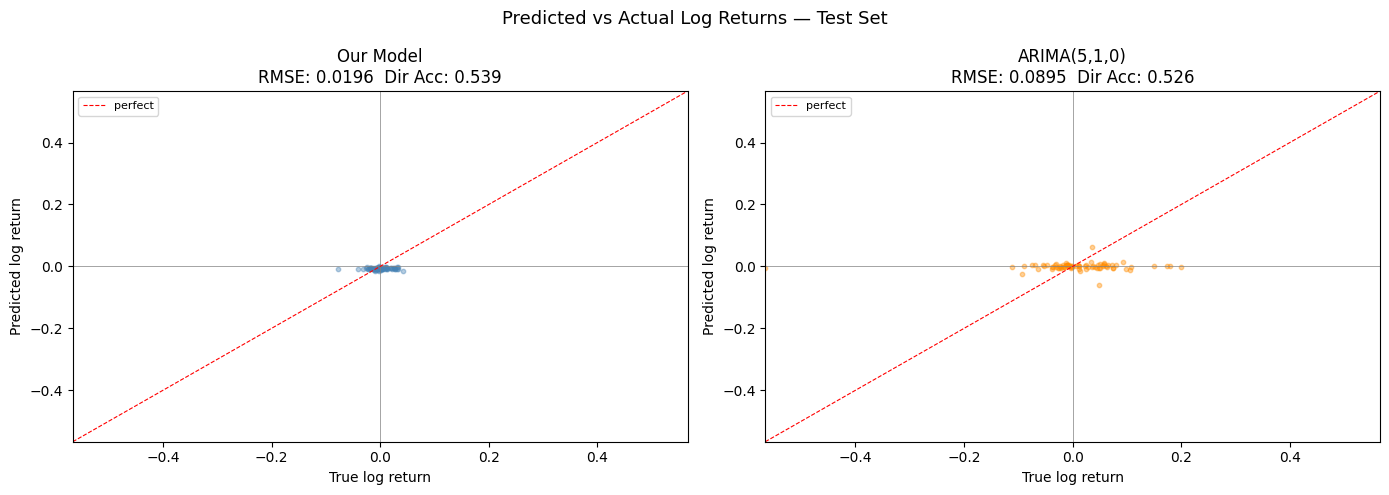

Plot saved to model_comparison.png


comparison/arima_corr,▁
comparison/arima_dir_acc,▁
comparison/arima_mae,▁
comparison/arima_rmse,▁
comparison/our_corr,▁
comparison/our_dir_acc,▁
comparison/our_mae,▁
comparison/our_rmse,▁
comparison/arima_corr,0.04592
comparison/arima_dir_acc,0.52564
comparison/arima_mae,0.05403


In [9]:
# ── Cell 7.5: ARIMA Comparison ─────────────────────────────────────────────────
def print_comparison(model_results, arima_rmse, arima_mae, arima_dir_acc, arima_corr):
    print(f"\n{'═'*58}")
    print(f"{'Model Comparison':^58}")
    print(f"{'═'*58}")
    print(f"{'Metric':<28} {'Our Model':>14} {'ARIMA':>14}")
    print(f"{'─'*58}")
    print(f"{'RMSE':<28} {model_results['rmse']:>14.6f} {arima_rmse:>14.6f}")
    print(f"{'MAE':<28} {model_results['mae']:>14.6f} {arima_mae:>14.6f}")
    print(f"{'Directional Accuracy':<28} {model_results['dir_acc']:>14.4f} {arima_dir_acc:>14.4f}")
    print(f"{'Correlation':<28} {model_results['corr']:>14.4f} {arima_corr:>14.4f}")
    print(f"{'─'*58}")

    print("\nWinner per metric:")
    metrics = [
        ("RMSE (lower is better)",         model_results['rmse'],    arima_rmse,    False),
        ("MAE (lower is better)",          model_results['mae'],     arima_mae,     False),
        ("Dir Accuracy (higher is better)",model_results['dir_acc'], arima_dir_acc, True),
        ("Correlation (higher is better)", arima_corr,    model_results['corr'],    True),
    ]
    for name, our_val, arima_val, higher_better in metrics:
        winner = "Our model" if (our_val > arima_val) == higher_better else "ARIMA"
        print(f"  {name:<38} → {winner}")
    print(f"{'═'*58}\n")


def plot_comparison(model_results, arima_preds, arima_true,
                    arima_rmse, arima_dir_acc):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Determine a common scale for both plots
    all_values = np.concatenate([
        model_results['trues'], model_results['preds'],
        arima_true, arima_preds
    ])
    common_lim = abs(all_values).max() # Removed * 1.1

    # Our model scatter
    axes[0].scatter(model_results['trues'], model_results['preds'],
                    alpha=0.4, s=10, color='steelblue')
    axes[0].axhline(0, color='gray', linewidth=0.5)
    axes[0].axvline(0, color='gray', linewidth=0.5)
    axes[0].plot([-common_lim, common_lim], [-common_lim, common_lim], 'r--', linewidth=0.8, label='perfect')
    axes[0].set_xlim(-common_lim, common_lim)
    axes[0].set_ylim(-common_lim, common_lim)
    axes[0].set_xlabel("True log return")
    axes[0].set_ylabel("Predicted log return")
    axes[0].set_title(f"Our Model\nRMSE: {model_results['rmse']:.4f}  "
                      f"Dir Acc: {model_results['dir_acc']:.3f}")
    axes[0].legend(fontsize=8)

    # ARIMA scatter
    axes[1].scatter(arima_true, arima_preds,
                    alpha=0.4, s=10, color='darkorange')
    axes[1].axhline(0, color='gray', linewidth=0.5)
    axes[1].axvline(0, color='gray', linewidth=0.5)
    axes[1].plot([-common_lim, common_lim], [-common_lim, common_lim], 'r--', linewidth=0.8, label='perfect')
    axes[1].set_xlim(-common_lim, common_lim)
    axes[1].set_ylim(-common_lim, common_lim)
    axes[1].set_xlabel("True log return")
    axes[1].set_ylabel("Predicted log return")
    axes[1].set_title(f"ARIMA(5,1,0)\nRMSE: {arima_rmse:.4f}  "
                      f"Dir Acc: {arima_dir_acc:.3f}")
    axes[1].legend(fontsize=8)

    plt.suptitle("Predicted vs Actual Log Returns — Test Set", fontsize=13)
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved to model_comparison.png")


# ── Run comparison ─────────────────────────────────────────────────────────────
# arima_rmse, arima_mae, arima_dir_acc, arima_corr,
# arima_preds, arima_true all come from Cell 3.5

print_comparison(test_results, arima_rmse, arima_mae, arima_dir_acc, arima_corr)
plot_comparison(test_results, arima_preds, arima_true, arima_rmse, arima_dir_acc)

# Log joint comparison to wandb for dashboard
with wandb.init(project="crypto-multi-stream", name="arima_comparison",
                reinit=True) as run:
    run.log({
        "comparison/our_rmse":      test_results['rmse'],
        "comparison/our_mae":       test_results['mae'],
        "comparison/our_dir_acc":   test_results['dir_acc'],
        "comparison/our_corr":      test_results['corr'],
        "comparison/arima_rmse":    arima_rmse,
        "comparison/arima_mae":     arima_mae,
        "comparison/arima_dir_acc": arima_dir_acc,
        "comparison/arima_corr":    arima_corr,
    })

    # Bar chart comparison logged to wandb
    metrics     = ["RMSE", "MAE", "Dir Accuracy", "Correlation"]
    our_vals    = [test_results['rmse'], test_results['mae'],
                   test_results['dir_acc'], test_results['corr']]
    arima_vals  = [arima_rmse, arima_mae, arima_dir_acc, arima_corr]

    comparison_table = wandb.Table(
        columns=["Metric", "Our Model", "ARIMA"],
        data=[[m, o, a] for m, o, a in zip(metrics, our_vals, arima_vals)]
    )
    run.log({"model_comparison_table": comparison_table})

In [10]:
# ── Cell 8: Hyperparameter Search ─────────────────────────────────────────────
import itertools
import random

param_grid = {
    "hidden_dim": [32, 64],
    "lr":         [1e-3, 5e-4, 1e-4],
    "dropout":    [0.2, 0.3],
    "seq_len":    [7],
    "stride":     [4, 5, 6],
    "num_gru_layers": [1, 2, 3] # Added num_gru_layers
}

random.seed(42)
keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
random.shuffle(combos)
search_configs = [dict(zip(keys, c)) for c in combos[:15]]

best_config   = None
best_val_loss = float("inf")
search_results = []

for i, cfg in enumerate(search_configs):
    print(f"\n── Config {i+1}/15: {cfg}")

    train_ds = CryptoDataset(train_df, window_size=cfg["seq_len"], stride=cfg["stride"])
    val_ds   = CryptoDataset(val_df,   window_size=cfg["seq_len"], stride=cfg["stride"])
    t_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    v_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    with wandb.init(project="crypto-multi-stream",
                    name=f"sweep-{i+1}",
                    config=cfg,
                    reinit=True) as run:

        m = CryptoMultiStreamModel(
            price_feat=PRICE_FEAT,
            chain_feat=CHAIN_FEAT,
            sent_feat=SENT_FEAT,
            hidden_dim=cfg["hidden_dim"],
            dropout=cfg["dropout"],
            num_gru_layers=cfg["num_gru_layers"] # Pass num_gru_layers
        ).to(device)

        opt     = torch.optim.Adam(m.parameters(), lr=cfg["lr"])
        loss_fn = nn.MSELoss()
        best_v  = float("inf")
        patience_counter = 0
        global_step      = 0

        for epoch in range(30):
            m.train()
            train_losses = []

            for x_price, x_chain, x_sent, y in t_loader:
                x_price, x_chain, x_sent, y = (
                    x_price.to(device), x_chain.to(device),
                    x_sent.to(device),  y.to(device)
                )
                opt.zero_grad()
                loss = loss_fn(m(x_price, x_chain, x_sent), y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
                opt.step()
                train_losses.append(loss.item())
                global_step += 1

            avg_train = np.mean(train_losses)
            m.eval()
            v_losses = []

            with torch.no_grad():
                for x_price, x_chain, x_sent, y in v_loader:
                    x_price, x_chain, x_sent, y = (
                        x_price.to(device), x_chain.to(device),
                        x_sent.to(device),  y.to(device)
                    )
                    v_losses.append(loss_fn(m(x_price, x_chain, x_sent), y).item())

            avg_v = np.mean(v_losses)
            wandb.log({
                "train_loss":  avg_train,
                "val_loss":    avg_v,
                "global_step": global_step
            })

            if avg_v < best_v:
                best_v           = avg_v
                patience_counter = 0
            else:
                patience_counter += 1

            # Early stopping inside search too
            if patience_counter >= 5:
                print(f"   Early stop at epoch {epoch+1}")
                break

        wandb.run.summary["best_val_loss"] = best_v
        search_results.append({"config": cfg, "val_loss": best_v})
        print(f"   Best val loss: {best_v:.6f}")

        if best_v < best_val_loss:
            best_val_loss = best_v
            best_config   = cfg
            torch.save(m.state_dict(), "best_search_model.pt")

print(f"\n{'═'*50}")
print(f"Best config found: {best_config}")
print(f"Best val loss:     {best_val_loss:.6f}")


── Config 1/15: {'hidden_dim': 64, 'lr': 0.001, 'dropout': 0.2, 'seq_len': 7, 'stride': 5, 'num_gru_layers': 3}


   Early stop at epoch 7
   Best val loss: 0.000950


global_step,▁▂▃▅▆▇█
train_loss,█▂▂▂▁▁▁
val_loss,▁▁█▅▃▄▃
best_val_loss,0.00095
global_step,63
train_loss,0.00244
val_loss,0.00106



── Config 2/15: {'hidden_dim': 32, 'lr': 0.001, 'dropout': 0.3, 'seq_len': 7, 'stride': 4, 'num_gru_layers': 1}


   Early stop at epoch 9
   Best val loss: 0.000936


...

global_step,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_loss,██▇▇▆▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁
best_val_loss,0.00153
global_step,180
train_loss,0.00212
val_loss,0.00179



── Config 15/15: {'hidden_dim': 64, 'lr': 0.001, 'dropout': 0.3, 'seq_len': 7, 'stride': 5, 'num_gru_layers': 3}


   Early stop at epoch 10
   Best val loss: 0.000817


global_step,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▂▁▁▁▁
val_loss,▂▂█▃▁▂▃▆▆▇
best_val_loss,0.00082
global_step,90
train_loss,0.00205
val_loss,0.00099



══════════════════════════════════════════════════
Best config found: {'hidden_dim': 32, 'lr': 0.001, 'dropout': 0.2, 'seq_len': 7, 'stride': 4, 'num_gru_layers': 2}
Best val loss:     0.000777
